**N4_total_results**: Analysis of all results obtained so far to get a total perspective (uses the last version only and compares RR's in a given observation and the alpha values obtained for each observation using the best RR's).

## 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation as sim
import natsort
import sys
sys.path.insert(0, './initialization/')
from imports import *
import parameters as pm
from pathlib import Path
import re


## 2. Creating file of final results so far

We now go into all results obtained so far (excluding the older versions), and create a DataFrame, which stores:
- The type of RR + cost function + mask used for the minimization (this is the hierarchical three-tiered "index");
- The satellite + signal name (these are the hierarchical two-tiered "columns");
- The alpha values obtained for each satellite+signal in each RR+CF+mask (these are the values stored);

This way, for each observation we create a DataFrame which summaries the results obtained; it should have some 150 columns (the number of alphas that we fit) and some 8 (RRs) x 24 (masks+CF) = 170 lines (the number of fits performed). 

In [78]:
# iterating over all result folders
for block_folder in Path("results").iterdir():

    # getting block
    if (not block_folder.is_dir()) or (block_folder.name[0] == "."):  continue
    if "old" in block_folder.name:  continue
    block = block_folder.name.split("_")[0]
    results = []
    print(f"Creating summary for {block}... ", end="")

    # iterating over each RR
    for RR_folder in block_folder.iterdir():

        # getting ridge-regularization lambda
        if (not RR_folder.is_dir()) or (RR_folder.name[0] == "."):  continue
        if RR_folder.name == "noRR":  RR = None
        else:  RR = int(RR_folder.name[2:])

        # iterating over each mask+CF result
        for file in RR_folder.glob("*.p"):

            # getting mask and CF
            CF = int(file.name[-3])
            mask = file.name.split("_")[0]

            # loading results
            with open(file, "rb") as f:  data = pickle.load(f)
            alphas = data["best-fit"]
            results.append((mask,CF,RR,alphas))

    # create three-level index
    index = pd.MultiIndex.from_tuples([
        (mask,CF,RR) for mask,CF,RR,alpha in results],
        names=["Mask","CF","RR"])
    alphas = [alpha for mask,CF,RR,alpha in results]

    # creating columns
    cat = pd.read_csv(pm.folder + f"catalog_{block}.csv")
    cat = cat[cat["Frequency(MHz)"] >= pm.freq_slice[0]]
    cat = cat[cat["Frequency(MHz)"] <= pm.freq_slice[1]]
    sigs = cat["Signal"].to_list()
    sats = cat["NORAD ID"].to_list()
    columns = pd.MultiIndex.from_tuples(
        list(zip(sats, sigs)),
        names=["Satellite", "Signal"])

    # creating dataframe
    df = pd.DataFrame(alphas, index=index, columns=columns)
    df = df.sort_index(level=["Mask","CF","RR"], na_position="first")
    df.to_csv(f"results/{block}_summary.csv")
    print("done!")
    

Creating summary for 1554156377... done!
Creating summary for 1556138397... done!
Creating summary for 1562857793... done!
Creating summary for 1553966342... done!
Creating summary for 1551055211... done!


## 3. Creating final "best RR" results file

We can now analyse the results obtained; for example, we can begin by inspect up to which RR we can go in each case (mask+CF+observation) and save that RR value, in order to create a "final result" for each mask+CF+observation.

In [348]:
# selecting block
block = 1551055211


In [349]:
# selecting paths
path_beam = "{}satbeams_{}_{}_{}-{}.pkl".format(pm.folder, block, pm.beam_model, *pm.freq_range)
path_catalog = f"{pm.folder}catalog_{block}.csv"
path_nearby = f"{pm.folder}nearby_{block}.pkl"
path_observations = f"/idia/projects/hi_im/satellite_rfi/Testing/{block}/{block}_average_TOD_BG_model.p"

# recovering katdal information
path_katdal = f"/idia/projects/hi_im/satellite_rfi/Testing/{block}/{block}_katdal_info.p"
katdal = pickle.load(open(path_katdal,"rb"), encoding="latin1")
nd_s0 = katdal["nd_s0"]
frequency = katdal["frequency"]
del katdal

# recovering summary
summary = pd.read_csv(f"results/{block}_summary.csv", header=[0,1], index_col=[0,1,2])
print(f"Masks present in the block {block} are:")
print(summary.index.get_level_values('Mask').unique().to_list())

# creating satellite simulation
sat = sim.SatelliteSimulation(
    survey_info=[nd_s0, frequency],
    path_catalog=path_catalog,
    path_beam=path_beam,
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=(None,None),
    label_sats="NORAD ID",
    verbose=True,
)

# getting observations and general quantities
sat.use_observations(path_observations=path_observations, verbose=True)
frequency = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
time = sat.time[sat.itime[0]:sat.itime[1]]
N = len(sat.catalog)


Masks present in the block 1551055211 are:
['deg1', 'deg5', 'interval2200-2400', 'interval5500-6200', 'interval775-1000', 'nomask', 'pix2', 'pix5', 'pix7', 'thermal100', 'thermal25', 'thermal50']
Getting catalog...
 - Number of signals in satellite catalog: 248 (initial), 131 (final).
 - Shape of dimensions is Nt,Nf = 2204,1199
Getting beam response...
 - Number of satellites present: 60
 - Size of sat_beam: 1.181 GB
Getting temperature factors for each signal...
 - Length of Tb_factors: 131
 - Size of Tb_factors: 0.001 GB
Getting observational data...
 - Size of observational data: 0.020 GB
 - Shape of observational data: (1199, 2204)


In [5]:
def select_mask(mask,sat,apply):
    '''Convert mask from summary into application.'''
    if mask.startswith("nomask"):
        sat.use_mask(apply=apply)
    elif mask.startswith("deg"):  
        par = pickle.load(open(path_nearby, "rb"))[int(mask[-1])]
        sat.use_mask(deg=par, apply=apply)
    elif mask.startswith("interval"):
        sat.use_mask(apply=apply)
    elif mask.startswith("pix"):
        sat.use_mask(pix=int(mask[-1]),apply=apply)
    elif mask.startswith("thermal"):  
        sat.use_mask(temp=int(mask[7:]), apply=apply)


In [351]:
# selecting mask -- better to do this one at a time and manually selecting the best
mask = "nomask"
select_mask(mask,sat,apply=False)


 ---------------- CHECKING FOR nomask ---------------- 
CHECKING COST FUNCTION CF = 1


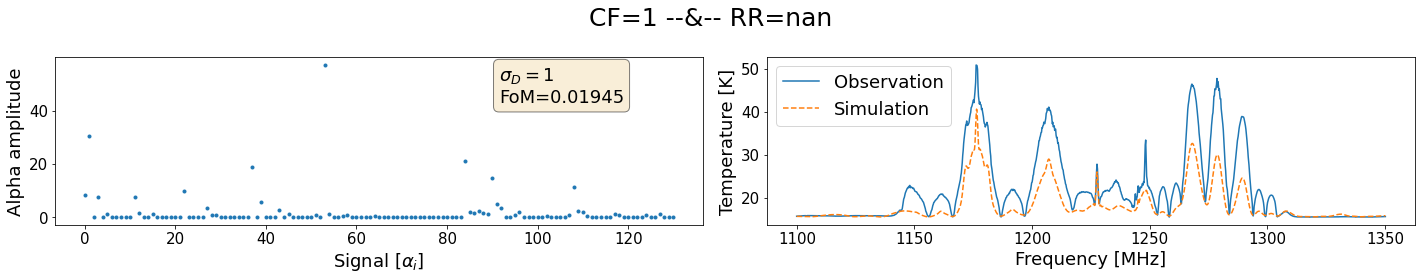

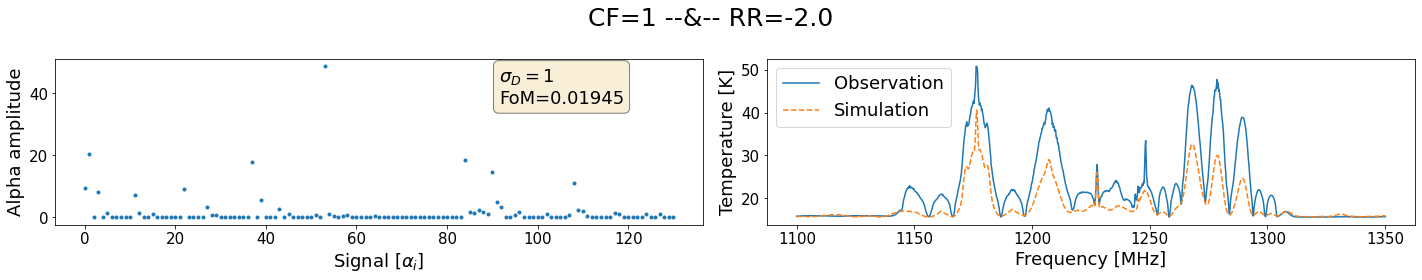

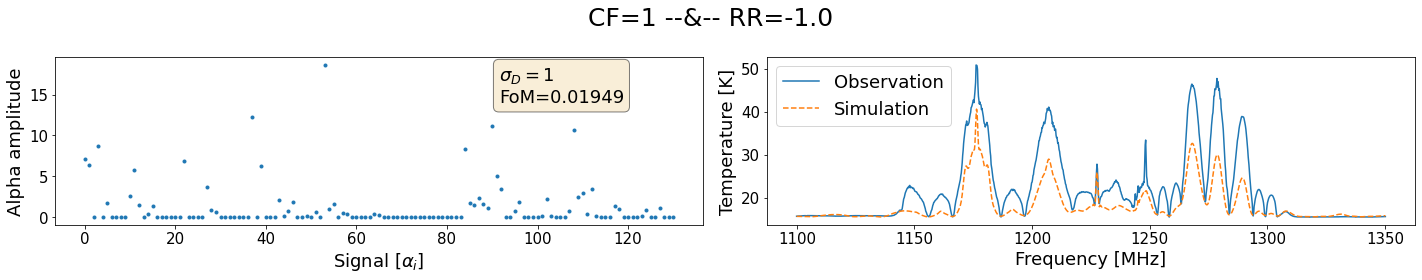

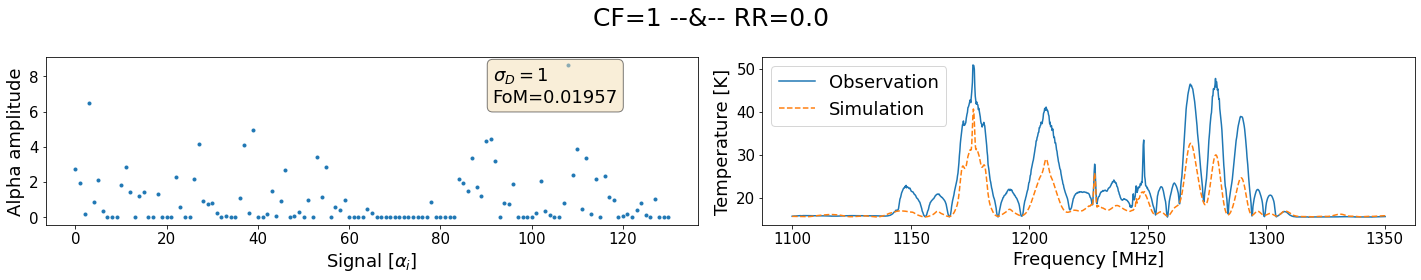

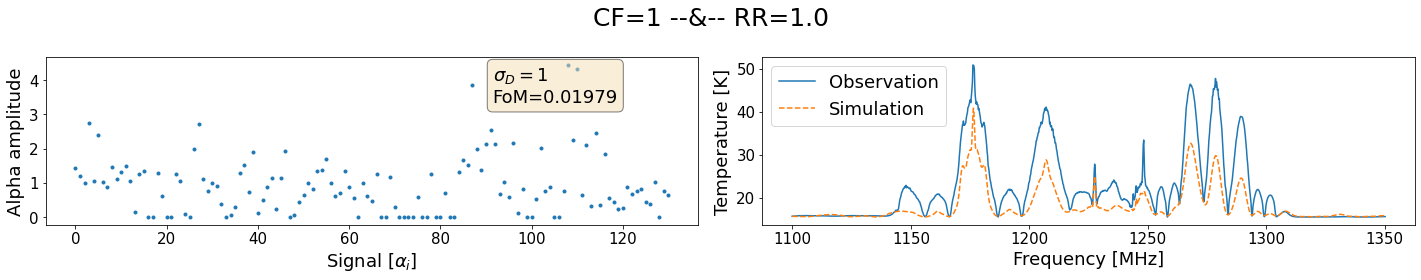

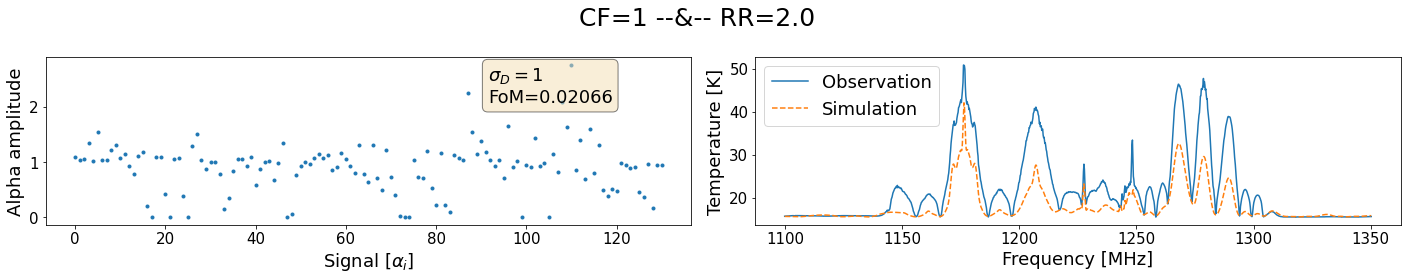

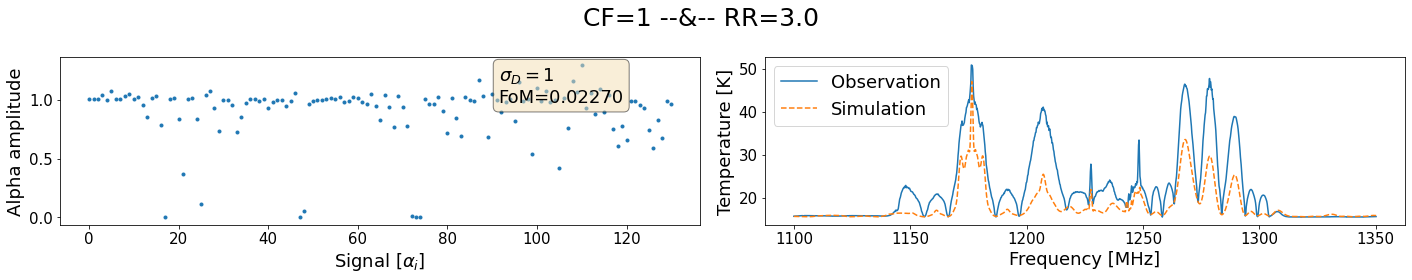

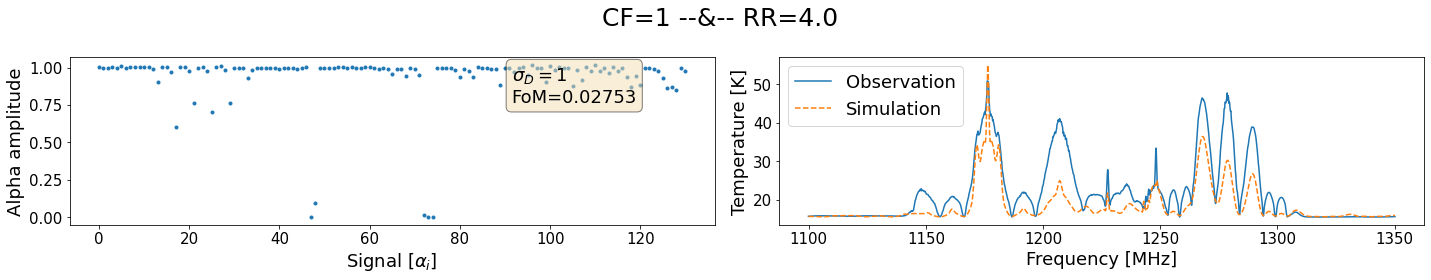

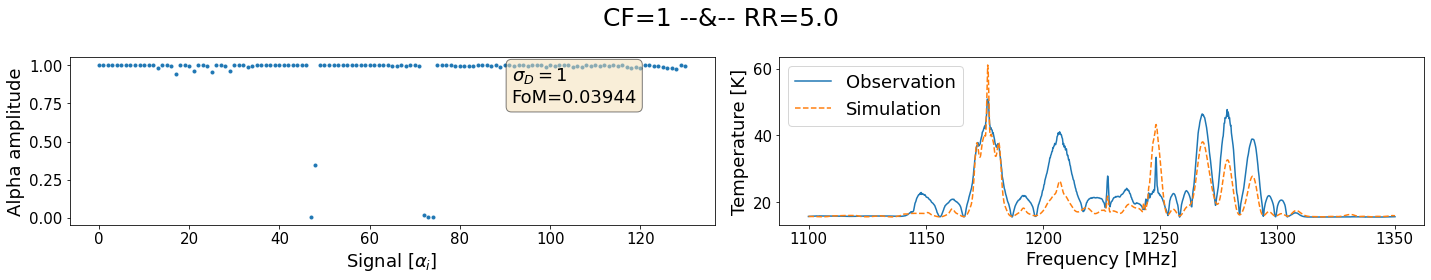

CHECKING COST FUNCTION CF = 2


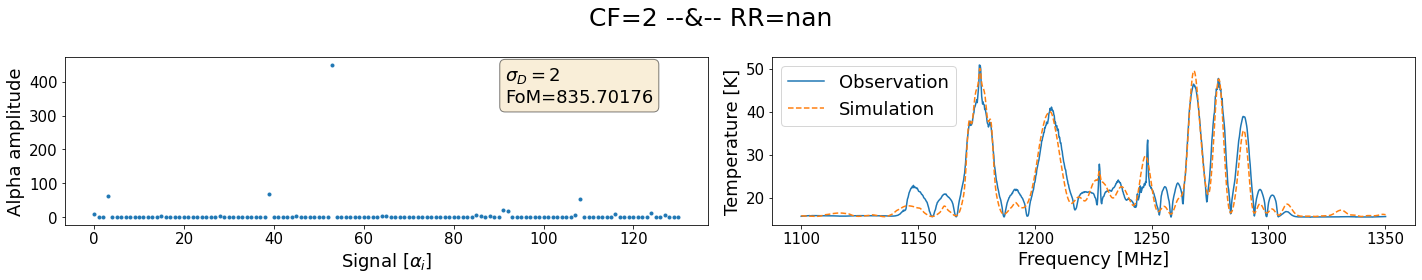

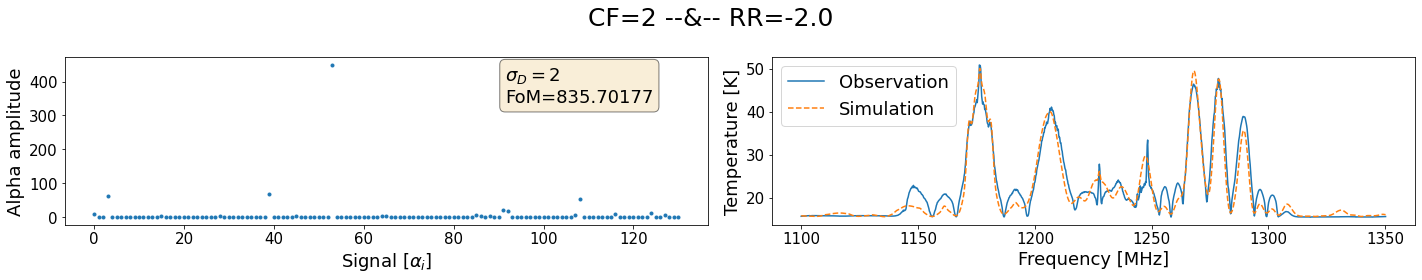

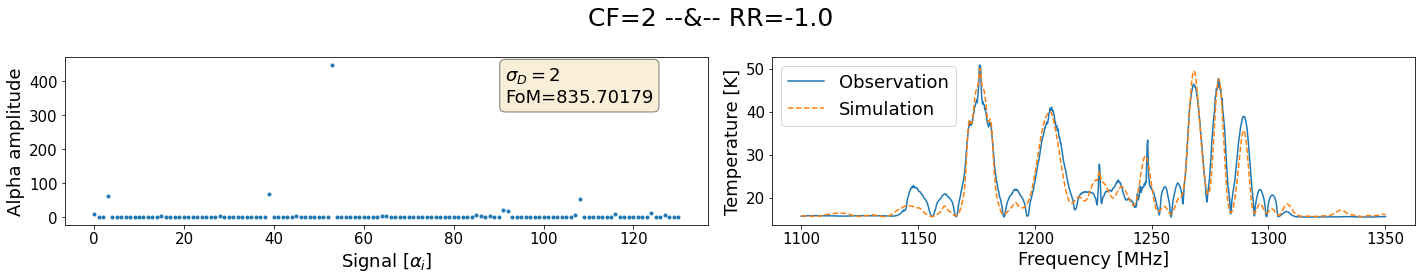

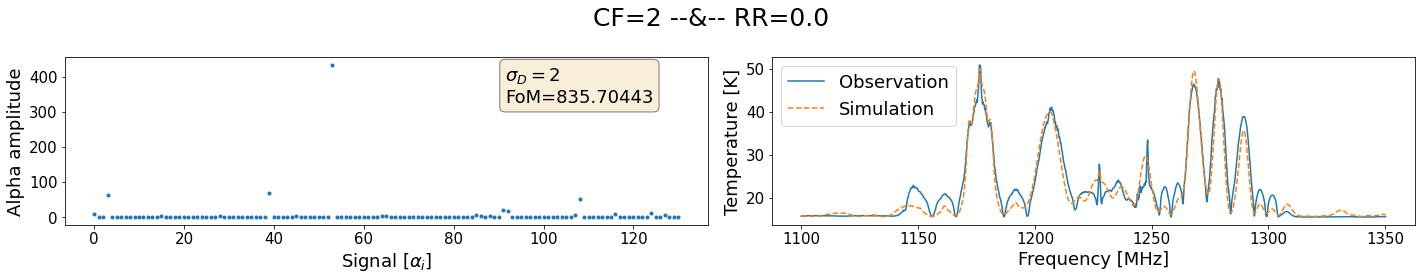

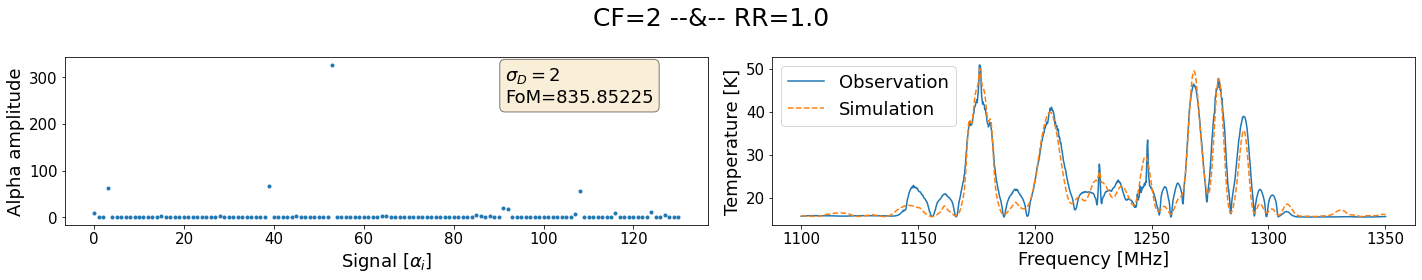

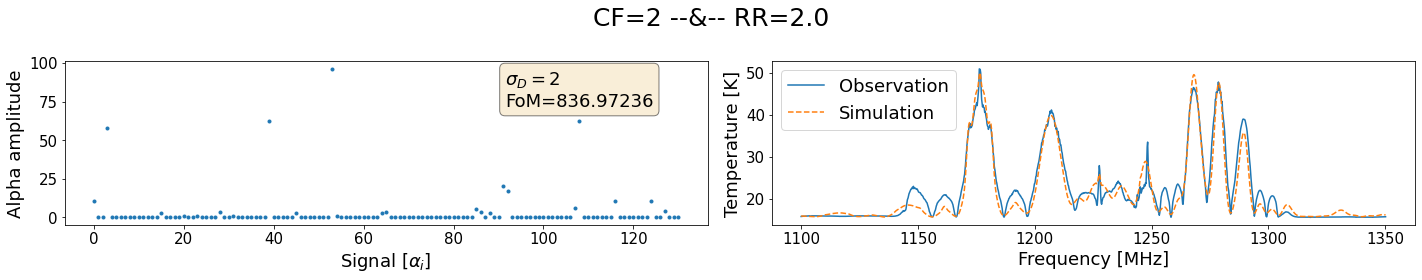

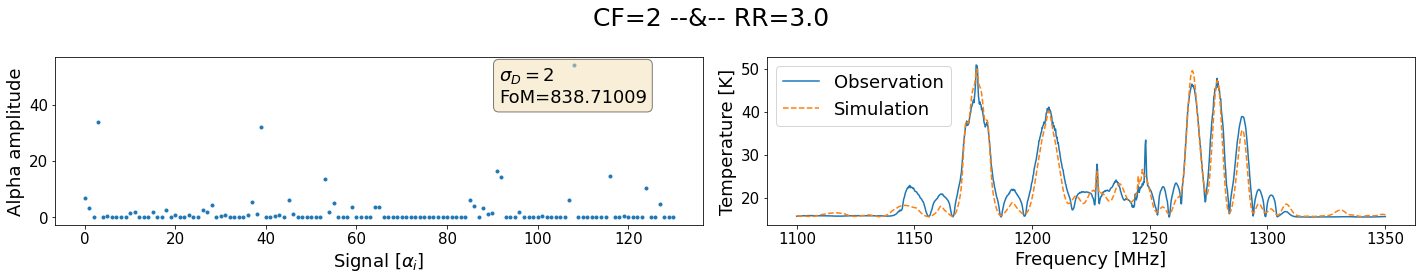

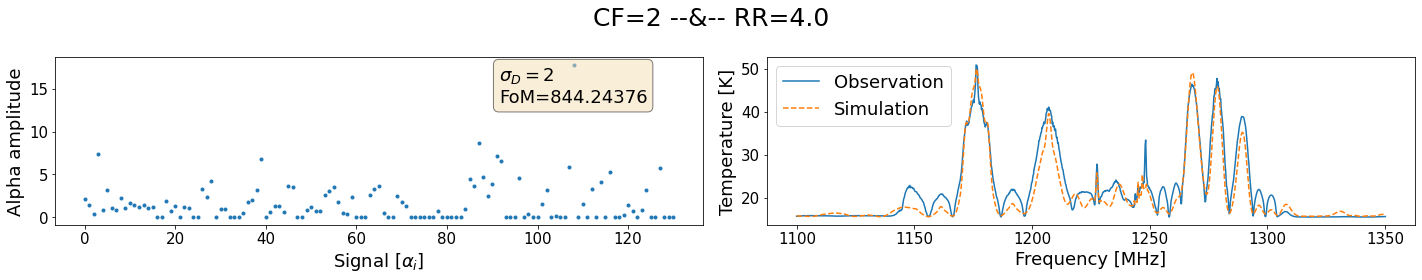

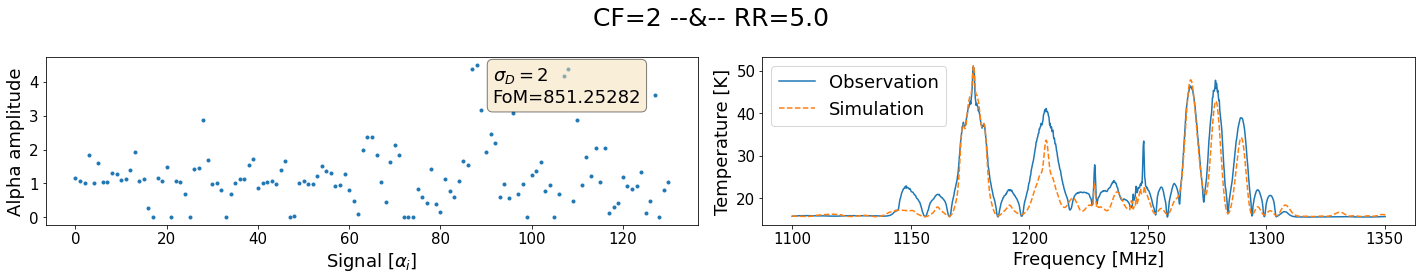

In [352]:
# getting quantities
obs_BGsub = np.ma.masked_equal(sat.obs_BGsub.T*sat.mask.T,0)
obs = np.ma.masked_equal(sat.obs.T*sat.mask.T,0)
Npoints = sat.mask[sat.mask].size

# iterating over CF and RR
print(f" ---------------- CHECKING FOR {mask} ---------------- ")
for CF in summary.loc[mask].index.get_level_values("CF").unique():
    print(f"CHECKING COST FUNCTION CF = {CF}")
    for RR, row in summary.loc[(mask, CF)].iterrows():

        # getting simulation
        alphas = row.to_numpy()
        sat.simulate(alphas)
        simul = np.ma.masked_equal(sat.sim.T*sat.mask.T,0)
        matrix = obs_BGsub - simul
        if CF==1:  CF_value = np.sum((matrix/obs)**2) / Npoints
        else:  CF_value = np.sum(matrix**2) / Npoints

        # creating figure
        fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=False, sharey=False)
        fig.suptitle(f'CF={CF} --&-- RR={RR}')
    
        # first figure - alphas
        axs[0].plot(alphas,".")
        axs[0].set_xlabel(r'Signal $[\alpha_{i}]$')
        axs[0].set_ylabel('Alpha amplitude')
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        textstr = f"$\\sigma_{{D}}={CF}$\nFoM={CF_value:.5f}"
        axs[0].text(0.685, 0.95, textstr, transform=axs[0].transAxes, 
                    fontsize=18, verticalalignment='top', bbox=props)
        
        # second figure - 1d simulation vs. observation
        axs[1].plot(frequency, np.ma.mean(obs, axis=0), label='Observation')
        axs[1].plot(frequency, np.ma.mean(simul+sat.BG.T, axis=0), '--', label='Simulation')
        axs[1].set_ylabel('Temperature [K]')
        axs[1].set_xlabel('Frequency [MHz]')
        axs[1].legend(loc="upper left")
    
        # showing figure
        fig.tight_layout()
        plt.show()
        

In [309]:
# selecting the best value for RR
C1_bestRR = -1
C2_bestRR = 2


In [310]:
# creating columns
print("Creating new entries... ",end="")
cat = pd.read_csv(path_catalog)
cat = cat[cat["Frequency(MHz)"] >= pm.freq_slice[0]]
cat = cat[cat["Frequency(MHz)"] <= pm.freq_slice[1]]
sats = [str(s) for s in cat["NORAD ID"].to_list()]
sigs = cat["Signal"].to_list()
columns = pd.MultiIndex.from_tuples(list(zip(sats,sigs)), names=["Satellite","Signal"])

# creating rows
new_index = pd.MultiIndex.from_tuples(
    [(block,mask,1,C1_bestRR), (block,mask,2,C2_bestRR)],
    names=["Block", "Mask", "CF", "RR"])

# creating dataframe
alphas_C1 = summary.loc[(mask, 1, C1_bestRR)].to_numpy()
alphas_C2 = summary.loc[(mask, 2, C2_bestRR)].to_numpy()
new_data = pd.DataFrame([alphas_C1,alphas_C2], index=new_index, columns=columns)
fname = "results/bestRRs.csv"

# writing it
if Path(fname).exists():
    bestRRs = pd.read_csv(fname, header=[0, 1], index_col=[0, 1, 2, 3])
    bestRRs = pd.concat([bestRRs, new_data], axis=0, sort=False)
else:
    bestRRs = new_data
print("done!")


Creating new entries... done!


In [311]:
# saving results (after checking that they are correct)
bestRRs.to_csv(fname)


## 4. Analysing results across different observations

Now we want to analyse the different results that we obtained and see if any trends appear - for example, maybe the alpha values for the signals are more or less similar across the different observations? And across the different satellites? 

Some plots to try:
- Scatter plot of alpha x integrated simulated signal (to check if the biggest alpha values correspond also to the ones with low signal and so are just fitting to noise; at the same time alphas that are exactly zero could be due to very low simulated signal as well); done for each block + mask + CF.
- 

#### A. Scatter plot of alpha and their signal strengths

We recover the quantities previously computed and plot the alphas with the highest contributions for a given mask + CF + block.

In [30]:
def block_setup(block):
    ''' Given a block, initializes the simulation. '''

    # getting results
    results = pd.read_csv("results/bestRRs.csv", header=[0, 1], index_col=[0, 1, 2, 3])
    results = results.sort_index()
    
    # selecting paths
    path_beam = "{}satbeams_{}_{}_{}-{}.pkl".format(pm.folder, block, pm.beam_model, *pm.freq_range)
    path_catalog = f"{pm.folder}catalog_{block}.csv"
    path_nearby = f"{pm.folder}nearby_{block}.pkl"
    path_observations = f"/idia/projects/hi_im/satellite_rfi/Testing/{block}/{block}_average_TOD_BG_model.p"
    
    # recovering katdal information
    path_katdal = f"/idia/projects/hi_im/satellite_rfi/Testing/{block}/{block}_katdal_info.p"
    katdal = pickle.load(open(path_katdal,"rb"), encoding="latin1")
    nd_s0 = katdal["nd_s0"]
    frequency = katdal["frequency"]
    del katdal
    
    # creating satellite simulation
    sat = sim.SatelliteSimulation(
        survey_info=[nd_s0, frequency],
        path_catalog=path_catalog,
        path_beam=path_beam,
        freq_range=pm.freq_range,
        freq_slice=pm.freq_slice,
        time_slice=(None,None),
        label_sats="NORAD ID",
        verbose=False,
    )
    
    # getting observations and general quantities
    sat.use_observations(path_observations=path_observations, verbose=False)
    return sat, results


In [32]:
# getting results
block = 1551055211
sat, results = block_setup(block)


In [33]:
# choose mask
mask = "deg1"
CF = 2
select_mask(mask,sat,apply=True)

# getting alpha values
print("Getting alpha values...")
row = results.loc[(block, mask, CF)]
alphas = row.iloc[0].to_numpy()
valid = ~np.isnan(alphas)
signals = results.columns.get_level_values("Signal").to_numpy()[valid]
sats = results.columns.get_level_values("Satellite").to_numpy()[valid]
alphas = alphas[valid]
zeros = (alphas==0)
RR = row.index[0]

# create matrix A
print("Creating matrix A...")
A = np.empty((sat.sat_beam[0].size, len(sat.catalog)))
for i_sat, start in enumerate(sat.index_sats):
    stop = start + sat.n_signals[i_sat]
    for i in range(start, stop):
        A[:, i] = (sat.sat_beam[i_sat] * sat.Tb_factors[i][:,None]).ravel()


Getting alpha values...
Creating matrix A...


In [41]:
def show_highest_contributors(alphas, quantity, quantity_obs, highs, title):
    ''' Plots checking the alphas that contribute the most to the simulation. '''

    # plotting
    plt.figure(figsize=(10, 5))
    plt.scatter(quantity, alphas)
    plt.scatter(quantity[(alphas==0)], alphas[(alphas==0)])

    # adding names
    for i in highs:
        label = f"{sats[i]} - {signals[i]}"
        x, y = quantity[i], alphas[i]
        plt.annotate(label, (x, y), xytext=(5, 5), textcoords="offset points")

    # showing figure
    plt.ylabel(r"$\alpha$")
    plt.xscale("log")
    if np.max(alphas) > 10:  plt.ylim(-0.5,10)
    plt.axvline(quantity_obs,ls="--",color="k")
    plt.title(title)
    plt.tight_layout()
    plt.show()


Showing block 1551055211, mask deg1, CF2 and RR=3


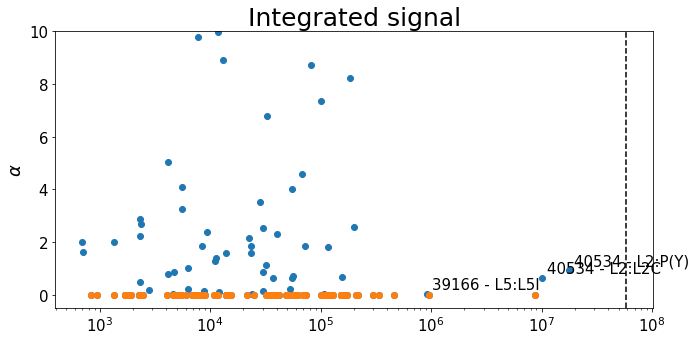

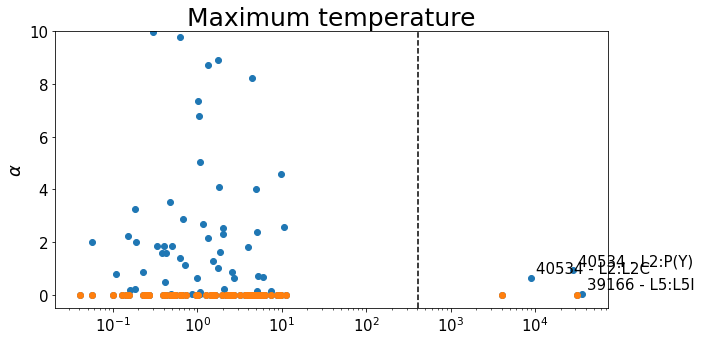

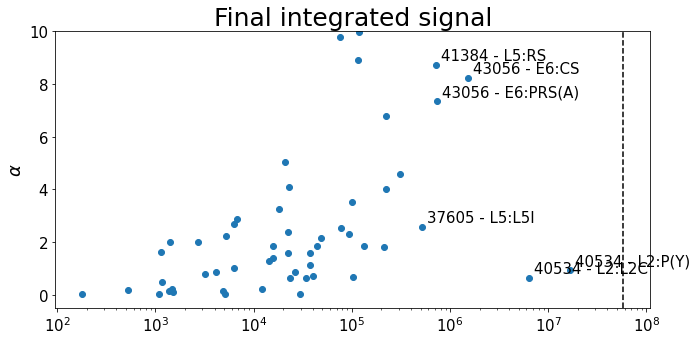

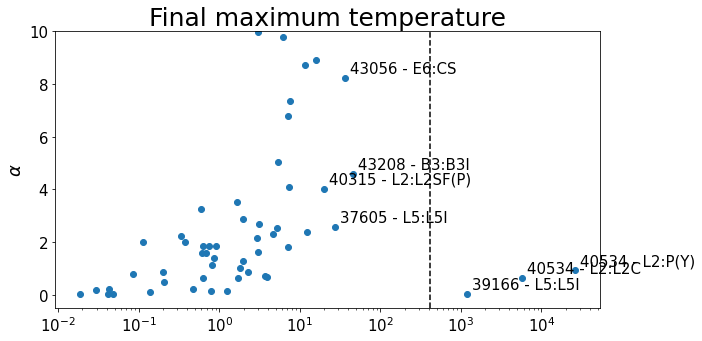

In [37]:
# showing integrated signal
print(f"Showing block {block}, mask {mask}, CF{CF} and RR={RR}")
integrated = np.sum(A, axis=0)
integrated_obs = np.sum(sat.obs)
integrated_highs = np.where((integrated>5*10**5) & (alphas!=0))[0]
show_highest_contributors(integrated, integrated_obs, integrated_highs, "Integrated signal")

# showing maximum temperature
temperature = np.max(A, axis=0)
temperature_obs = np.max(sat.obs)
temperature_highs = np.where((temperature>20) & (alphas!=0))[0]
show_highest_contributors(temperature, temperature_obs, temperature_highs, "Maximum temperature")

# multiplying by alpha
mult_integrated = integrated * alphas
mult_temperature = temperature * alphas
mult_integrated_highs = np.where((mult_integrated>5*10**5) & (alphas!=0))[0]
show_highest_contributors(mult_integrated, integrated_obs, mult_integrated_highs, "Final integrated signal")
mult_temperature_highs = np.where((mult_temperature>20) & (alphas!=0))[0]
show_highest_contributors(mult_temperature, temperature_obs, mult_temperature_highs, "Final maximum temperature")


#### B. Scatter plot of a specific alpha accross fittings and observations

We are now interested in the way that alpha changes accross the different fittings and observations. As such, we will plot the alpha values obtained for the differents fits (it might be good to plot all alphas for a given satellite at once, no?) and then see if we can add as well the different observations. 

<class 'pandas.core.series.Series'>
Block       Mask               CF  RR
1551055211  deg1               1    1    1.400352
                               2    3    2.226271
            deg5               1    0    2.584964
                               2    3    1.852715
            interval2200-2400  1   -1    1.000000
                                           ...   
1562857793  thermal100         2    3    0.839630
            thermal25          1   -1    4.123250
                               2    2    2.193065
            thermal50          1    1    1.029868
                               2    3    0.965777
Name: (22877, L2:P(Y)), Length: 108, dtype: float64


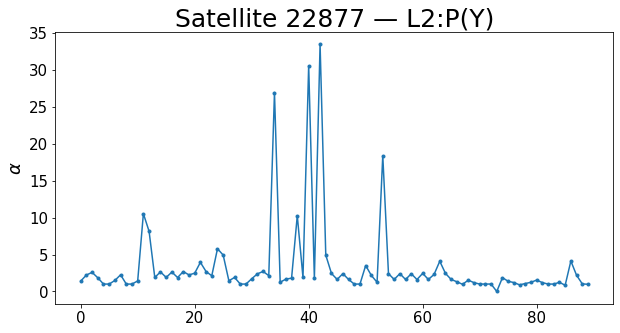

In [49]:
# choose a sat - signal
sat = "22877"
sig = "L2:P(Y)"

print(type(results[(sat, sig)]))
print(results[(sat, sig)])
values = results[(sat,sig)].dropna().to_numpy()

plt.figure(figsize=(10, 5))
plt.plot(values, ".-")
plt.ylabel(r"$\alpha$")
plt.title(f"Satellite {sat} — {sig}")
plt.show()

SyntaxError: unexpected EOF while parsing (<ipython-input-39-0ef7d1ff7986>, line 1)